# Kolkata Sales (Realestate) Report

In [2]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
df= pd.read_csv('real.csv')
df.head()

,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac


# Data Correction

## By Area

In [4]:
df['area'] = pd.to_numeric(df['Area'].str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['area'].fillna(np.mean(df['area']))
df.head()

,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price,area
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr,1850
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,525
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,705
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr,1612
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac,980


## By BHK

In [10]:
def extract_bhk(name):
    x=name.split()
    if "1" in x:
        return 1
    elif "2" in x:
        return 2
    elif "3" in x:
        return 3
    elif "4" in x:
        return 4
    elif "5" in x:
        return 5
    elif "6" in x:
        return 6
    elif "7" in x:
        return 7
    elif "8" in x:
        return 8
    elif "9" in x:
        return 9
    elif "10" in x:
        return 10
    else:
        return 0
def cor(x):
    if(x==0):
        return int(np.mean(df['BHK']))
    return x

df['BHK'] = df['Name'].apply(extract_bhk)
df['BHK']= df['BHK'].apply(cor)
df.head()

,Unnamed: 0,Name,Area,Furnishing,Transaction,Status,Price,area,BHK
0,0,4 BHK Apartment for Sale in Sugam Morya,1850 sqft,Unfurnished,Resale,Ready to Move,₹2.38 Cr,1850,4
1,1,2 BHK Apartment for Sale in Regent Park Kolkata,525 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,525,2
2,2,2 BHK Apartment for Sale in Parvati Garden,705 sqft,Unfurnished,Resale,Ready to Move,₹32 Lac,705,2
3,3,3 BHK Apartment for Sale in Multicon Estelle,1612 sqft,Unfurnished,Resale,Ready to Move,₹2.25 Cr,1612,3
4,4,2 BHK Apartment for Sale in Golpark Cooperativ...,980 sqft,Semi-Furnished,Resale,Ready to Move,₹50 Lac,980,2


# Statistical Summary
## By Area

In [12]:
df['area'].describe()

count    3000.000000
mean     1143.171667
std       783.439505
min       268.000000
25%       705.000000
50%       928.000000
75%      1612.000000
max      4400.000000
Name: area, dtype: float64

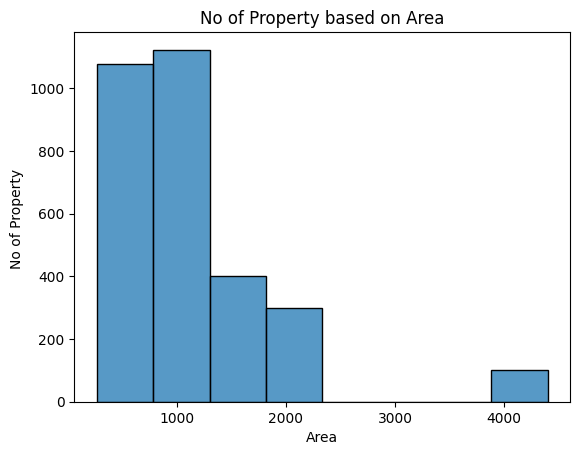

In [44]:
sns.histplot(df['area'],bins=8)
plt.title('No of Property based on Area')
plt.ylabel('No of Property ')
plt.xlabel('Area')
plt.show()

/var/folders/5_/7gwt7m_s7td86cpcklmhgplr0000gn/T/ipykernel_6349/185202675.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['area'],shade=True)


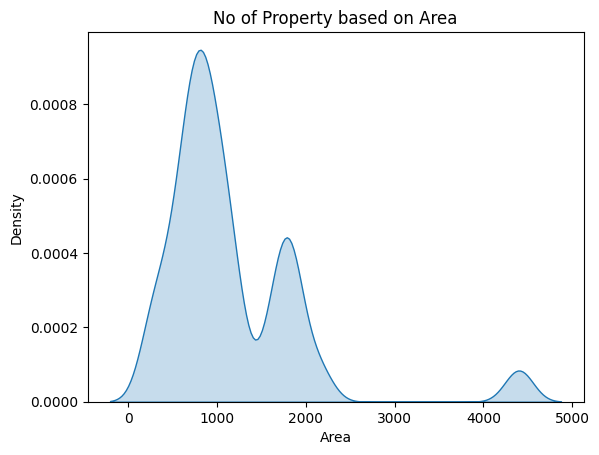

In [ ]:
sns.kdeplot(df['area'],shade=True)
plt.title('No of Property based on Density')
plt.xlabel('Area')
plt.show()

### By this we can conclude that most people prefer property in the range of 900-1200 BHK. So the real estate company must focus on building more properties within this range

## By BHK

In [14]:
df['BHK'].describe()

count    3000.000000
mean        2.674333
std         0.976350
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max         6.000000
Name: BHK, dtype: float64

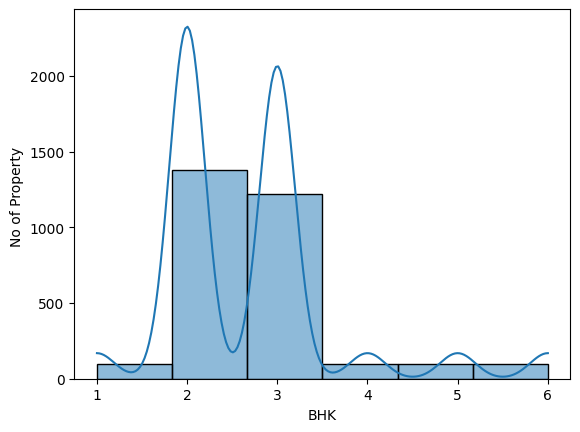

In [ ]:
sns.histplot(df['BHK'],bins=6)
plt.ylabel('No of Property ')
plt.show()